In [1]:
# pip install pymysql

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
from sklearn.preprocessing import LabelEncoder , MinMaxScaler , StandardScaler 
import os
import pymysql as sql

In [47]:
import os

def get_connection():
    return sql.connect(
        user="root",
        host="localhost",
        password=os.getenv("DB_PASSWORD"),
        database="pizza_store"
    )

In [48]:
cur = conn.cursor()

In [49]:
cur.execute(""" select * from order_Wise_details o join 
pizza_sales p on o.order_id = p.order_id
join pizza_wise_details pw 
on p.pizza_id = pw.pizza_id
join pizza_order po 
on o.order_id = po.order_id
and p.pizza_id = po.pizza_id; """)

1000

In [50]:
rows= cur.fetchall()

In [51]:
cols=[i[0] for i in cur.description]

In [52]:
df=pd.DataFrame(data=rows,columns=cols)

In [53]:
df.shape

(1000, 30)

In [16]:
df['order_id']= df['order_id'].astype(float)
df['total_price']= df['total_price'].astype(float)
df['unique_pizza_count']= df['unique_pizza_count'].astype(float)
df['unit_price']= df['unit_price'].astype(float)
df['quantity']= df['quantity'].astype(float)

In [17]:
df.columns

Index(['order_id', 'total_price', 'unique_pizza_count', 'total_qty',
       'order_date', 'unit_price', 'min_pizza_size', 'max_pizza_size',
       'unique_category_count', 'order_details_id', 'order_id', 'pizza_id',
       'quantity', 'order_date', 'order_time', 'unit_price', 'total_price',
       'pizza_size', 'pizza_category', 'pizza_ingredients', 'pizza_name',
       'pizza_id', 'pizza_name', 'Qty', 'unit_price', 'total_price',
       'pizza_size', 'ingredients', 'pizza_id', 'order_id'],
      dtype='object')

In [18]:
import pandas # importing liberary 
pizza_df = pd.DataFrame({}) # creating empty df 
for col in df.columns: 
    # starting loop with each column 
    if col not in pizza_df.columns: 
        # loop will work once the is not present in pizza_df
        if type(df[col])==pandas.core.frame.DataFrame: 
            # once duplicate colum found then it will return data frame 
            pizza_df[col] =  df[col].iloc[:,0] 
            # using iloc slicing 1st column of df of duplicate columns 
        else:
            pizza_df[col]= df[col] # column will be stored in pizza_df if it is not duplicate

In [19]:
pizza_df.columns

Index(['order_id', 'total_price', 'unique_pizza_count', 'total_qty',
       'order_date', 'unit_price', 'min_pizza_size', 'max_pizza_size',
       'unique_category_count', 'order_details_id', 'pizza_id', 'quantity',
       'order_time', 'pizza_size', 'pizza_category', 'pizza_ingredients',
       'pizza_name', 'Qty', 'ingredients'],
      dtype='object')

In [20]:
type(df)

pandas.core.frame.DataFrame

In [21]:
pizza_df.columns

Index(['order_id', 'total_price', 'unique_pizza_count', 'total_qty',
       'order_date', 'unit_price', 'min_pizza_size', 'max_pizza_size',
       'unique_category_count', 'order_details_id', 'pizza_id', 'quantity',
       'order_time', 'pizza_size', 'pizza_category', 'pizza_ingredients',
       'pizza_name', 'Qty', 'ingredients'],
      dtype='object')

In [22]:
total_orders = pizza_df['order_id'].nunique()

In [23]:
total_orders

439

In [24]:
Avg_price= pizza_df['total_price'].astype(float).mean()

In [25]:
Avg_price

np.float64(59.16310000000001)

In [26]:
Avg_pizza_qty = pizza_df['unique_pizza_count'].astype(float).mean()

In [27]:
round(Avg_pizza_qty)

3

In [28]:
top5_dates=pizza_df.groupby(
    'order_date').agg(
    {'order_date':'count'}).rename(
    columns={'order_date':'orders'}).sort_values(
    'orders',ascending=False).head(5).reset_index()

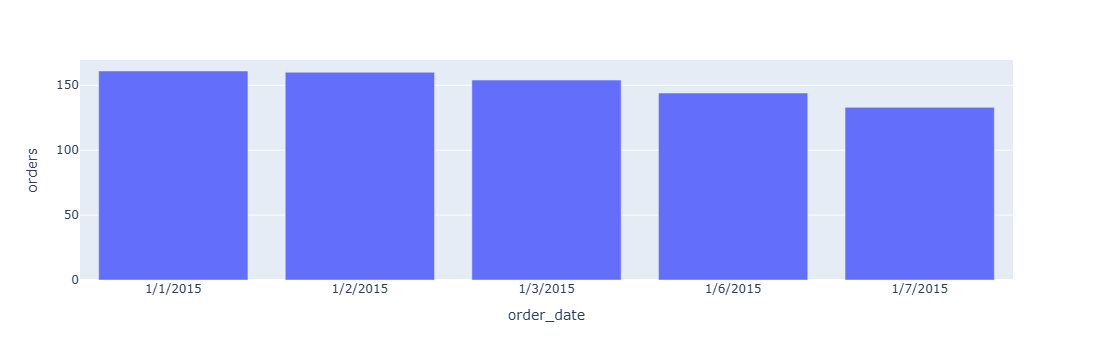

In [29]:
px.bar(top5_dates,x='order_date',y='orders')

In [30]:
pizza_df['total_qty']=pizza_df['total_qty'].astype(int)

In [31]:
pizza_size = pizza_df.groupby('min_pizza_size').agg({'total_qty':'sum'}).reset_index()

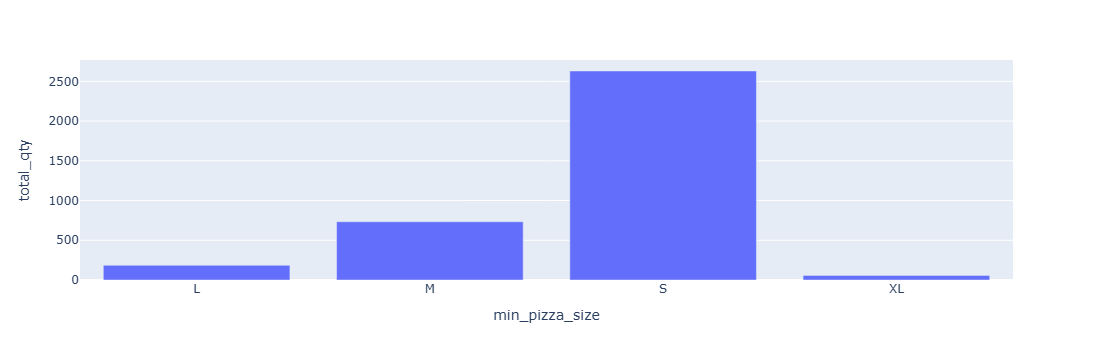

In [32]:
px.bar(pizza_size,x='min_pizza_size',y='total_qty')

In [33]:
pizza_df['full_date'] =  pizza_df['order_date']+' '+pizza_df['order_time']

In [34]:
pizza_df['full_date']=pd.to_datetime(pizza_df['full_date'],format='%m/%d/%Y %H:%M:%S')

In [35]:
hour_orders=pizza_df.groupby(pizza_df['full_date'].dt.hour).agg(
    {'order_id':'nunique'}).reset_index()

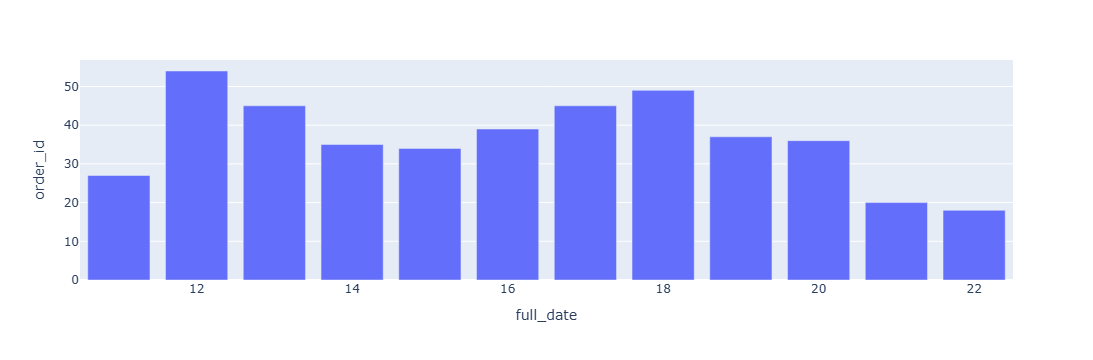

In [36]:
px.bar(hour_orders,x='full_date',y='order_id')

In [37]:
hour_orders

,full_date,order_id
0,11,27
1,12,54
2,13,45
3,14,35
4,15,34
5,16,39
6,17,45
7,18,49
8,19,37
9,20,36


In [38]:
pizza_df.columns

Index(['order_id', 'total_price', 'unique_pizza_count', 'total_qty',
       'order_date', 'unit_price', 'min_pizza_size', 'max_pizza_size',
       'unique_category_count', 'order_details_id', 'pizza_id', 'quantity',
       'order_time', 'pizza_size', 'pizza_category', 'pizza_ingredients',
       'pizza_name', 'Qty', 'ingredients', 'full_date'],
      dtype='object')

In [39]:
pizza_df['total_price']=pizza_df['total_price'].astype(float)
pizza_df['total_qty']=pizza_df['total_qty'].astype(float)
pizza_df['order_id']=pizza_df['order_id'].astype(float)

In [40]:
Pizza_table=pizza_df.groupby(
    'pizza_category').agg({
    'total_price':'mean','total_qty':'mean','order_id':'nunique'})

In [41]:
for col in Pizza_table.columns:
    if Pizza_table[col].dtypes!='obect':
        Pizza_table[col]=Pizza_table[col].apply(lambda x : round(x))

In [42]:
Pizza_table

,total_price,total_qty,order_id
pizza_category,,,
Chicken,61,4,175
Classic,58,4,226
Supreme,60,4,187
Veggie,59,4,183


In [43]:
pizza_df['full_date'].dt.day.unique()

array([1, 2, 3, 4, 5, 6, 7, 8], dtype=int32)

In [44]:
pizza_df['total_sale']=pizza_df['total_qty']*pizza_df['total_price']

In [45]:
day_sale=pizza_df.groupby(pizza_df['full_date'].dt.day).agg(
    {'total_sale':'sum'}).reset_index()

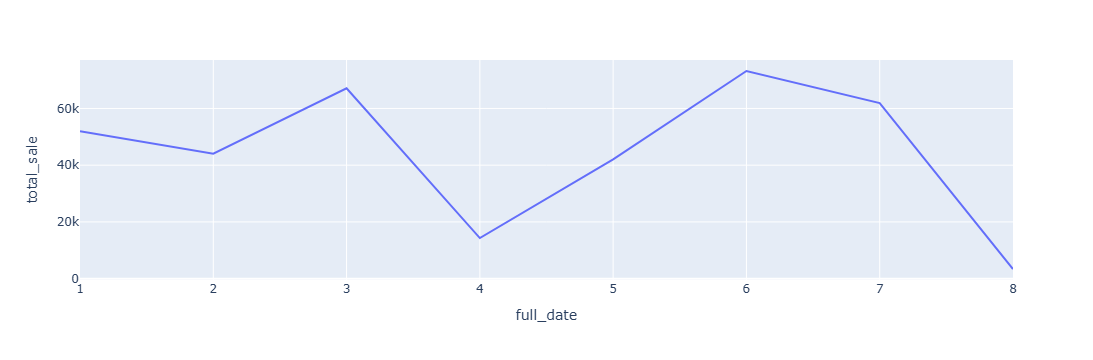

In [46]:
px.line(day_sale,x='full_date',y='total_sale')